# EEG Alcoholism Classification — Neural Network Setup

**Dataset:** UCI EEG Database (alcoholism study)  
**Task:** Binary classification — `alcoholic` vs `control`  
**Input format:** `compiled.csv` with columns `(subject, trial, condition, channel, sample, value)`  
**Signal:** 64 channels × 256 time samples per trial → shape `(64, 256)` per trial


## 1. Imports & Config

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# ── reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── hardware ─────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── hyper-parameters (edit freely) ───────────────────────────────────────────
CSV_PATH    = 'compiled.csv'   # path to your compiled dataset
N_CHANNELS  = 63               # EEG electrodes
N_SAMPLES   = 256              # time-points per trial @ 256 Hz → 1 second
BATCH_SIZE  = 32
EPOCHS      = 30
LR          = 1e-3
VAL_SPLIT   = 0.15             # fraction of data held out for validation
TEST_SPLIT  = 0.15             # fraction held out for final test

Using device: cpu


## 2. Load & Reshape Data

The CSV stores data in long format. We pivot each `(subject, trial)` pair into a
2-D array of shape `(n_channels, n_samples)` and store the group label.

In [2]:
df = pd.read_csv(CSV_PATH)
print(df.shape)
df.head()

(18966528, 6)


,subject,trial,condition,channel,sample,value
0,co2a0000364.rd,0,S1 obj,FP1,0,-8.921
1,co2a0000364.rd,0,S1 obj,FP1,1,-8.433
2,co2a0000364.rd,0,S1 obj,FP1,2,-2.574
3,co2a0000364.rd,0,S1 obj,FP1,3,5.239
4,co2a0000364.rd,0,S1 obj,FP1,4,11.587


In [6]:
# The group label is encoded in the subject ID:
# co2a... → alcoholic, co2c... → control (UCI EEG dataset convention).
# The 5th character (index 4) is 'a' or 'c'.

def extract_group(subject_str: str) -> str:
    """Return 'alcoholic' or 'control' from the subject ID string."""
    s = str(subject_str).lower()
    marker = s[3]   # 'co2a...' → index 4 is 'a'; 'co2c...' → 'c'
    if marker == 'a':
        return 'alcoholic'
    elif marker == 'c':
        return 'control'
    raise ValueError(f'Cannot parse group from subject ID: {subject_str!r}, where s[4] = {marker}')

df['group'] = df['subject'].apply(extract_group)
print(df['group'].value_counts())

group
alcoholic    9563904
control      9402624
Name: count, dtype: int64


In [20]:
# ── pivot to (trial, channel, sample) tensors ─────────────────────────────────

trial_keys = ['subject', 'trial']

# One group label per (subject, trial) pair
labels_df = (
    df.drop_duplicates(subset=trial_keys)[trial_keys + ['group']]
    .reset_index(drop=True)
)

# Pivot: rows = (subject, trial, channel), cols = sample index
pivoted = (
    df.pivot_table(
        index=trial_keys + ['channel'],
        columns='sample',
        values='value',
        aggfunc='first',
    )
    .reset_index()
)

# Build numpy array: shape (n_trials, n_channels, n_samples)
groups = pivoted.groupby(trial_keys)
trial_list = []
label_list = []

label_map = labels_df.set_index(trial_keys)['group']
sample_cols = pivoted.columns.difference(['subject', 'trial', 'channel'])
    

for key, grp in groups:
    # grp has one row per channel; sort to ensure consistent channel ordering
    grp_sorted = grp.sort_values('channel')

    grp_sorted = grp.sort_values('channel')

    signal = grp_sorted[sample_cols].values.astype(np.float32)
    
    if signal.shape != (N_CHANNELS, N_SAMPLES):
        # Skip incomplete trials
        continue
    trial_list.append(signal)
    label_list.append(label_map.loc[key])

X = np.stack(trial_list)   # (n_trials, 64, 256)
y_raw = np.array(label_list)

le = LabelEncoder()
y = le.fit_transform(y_raw).astype(np.int64)  # 0 = alcoholic, 1 = control (or vice-versa)

print(f'X shape : {X.shape}')   # (n_trials, 64, 256)
print(f'y shape : {y.shape}')
print(f'Classes : {le.classes_}')  # ['alcoholic', 'control']
print(f'Label counts: {np.bincount(y)}')

X shape : (1176, 63, 256)
y shape : (1176,)
Classes : ['alcoholic' 'control']
Label counts: [593 583]


## 3. Quick Signal Sanity-Check

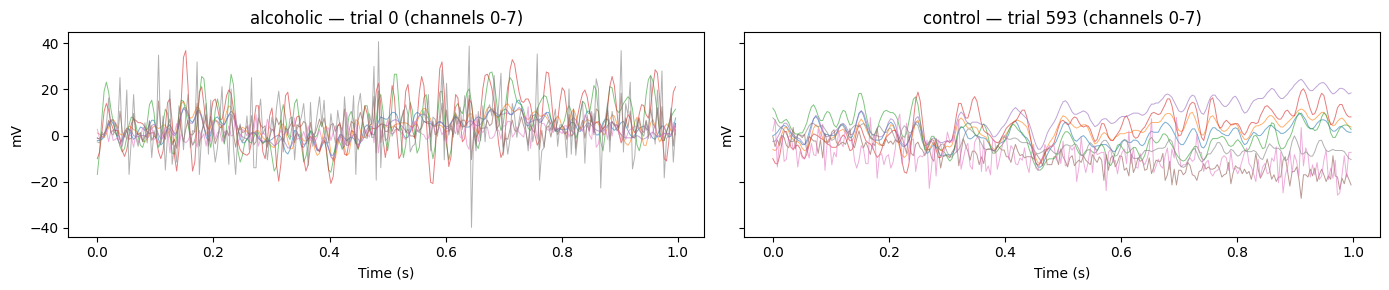

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharey=True)
t = np.arange(N_SAMPLES) / 256  # seconds

for ax, cls_idx, title in zip(axes, [0, 1], le.classes_):
    idx = np.where(y == cls_idx)[0][0]
    ax.plot(t, X[idx, :8, :].T, alpha=0.6, linewidth=0.7)  # first 8 channels
    ax.set_title(f'{title} — trial {idx} (channels 0-7)')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('mV')

plt.tight_layout()
plt.show()

## 4. Dataset & DataLoaders

In [24]:
class EEGDataset(Dataset):
    """Wraps the (n_trials, 64, 256) EEG array as a PyTorch Dataset."""

    def __init__(self, X: np.ndarray, y: np.ndarray):
        # Add a channel-dimension for Conv2d: (n_trials, 1, 64, 256)
        self.X = torch.from_numpy(X[:, np.newaxis, :, :])  # float32
        self.y = torch.from_numpy(y)                        # int64

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


full_ds = EEGDataset(X, y)

n_total = len(full_ds)
n_test  = int(n_total * TEST_SPLIT)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val - n_test

train_ds, val_ds, test_ds = random_split(
    full_ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train / Val / Test : {n_train} / {n_val} / {n_test} trials')

Train / Val / Test : 824 / 176 / 176 trials


## 5. Model Architecture — EEGNet-inspired CNN

EEGNet (Lawhern et al., 2018) uses depthwise separable convolutions tuned for EEG:

| Block | Operation | Purpose |
|---|---|---|
| Temporal conv | `Conv2d(1, F1, (1, 64))` | Spectral feature extraction |
| Depthwise spatial conv | `Conv2d(F1, D×F1, (64, 1), groups=F1)` | Learns spatial (electrode) filters |
| Separable conv | `Conv2d → pointwise` | Compact temporal summary |
| Classifier | `Linear → softmax` | Binary output |


In [25]:
class EEGNet(nn.Module):
    """
    EEGNet-8,2 — compact CNN for EEG classification.
    Input shape: (batch, 1, n_channels, n_samples)  →  (batch, 1, 64, 256)
    """

    def __init__(
        self,
        n_classes:  int = 2,
        n_channels: int = 64,
        n_samples:  int = 256,
        F1:         int = 8,    # temporal filters
        D:          int = 2,    # depth multiplier (spatial filters = D × F1)
        F2:         int = 16,   # separable filters
        dropout:    float = 0.5,
    ):
        super().__init__()
        F2 = D * F1  # kept consistent

        # ── Block 1: temporal + spatial convolution ───────────────────────────
        self.block1 = nn.Sequential(
            # Temporal convolution: kernel spans ~250 ms at 256 Hz → kernel_size 64
            nn.Conv2d(1, F1, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1),
            # Depthwise spatial: one filter per input channel, per temporal filter
            nn.Conv2d(F1, D * F1, kernel_size=(n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(D * F1),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),  # downsample time by 4
            nn.Dropout(dropout),
        )

        # ── Block 2: separable convolution ────────────────────────────────────
        self.block2 = nn.Sequential(
            # Depthwise
            nn.Conv2d(D * F1, D * F1, kernel_size=(1, 16), padding=(0, 8),
                      groups=D * F1, bias=False),
            # Pointwise
            nn.Conv2d(D * F1, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),  # downsample time by 8
            nn.Dropout(dropout),
        )

        # ── Classifier ────────────────────────────────────────────────────────
        # Compute flatten size analytically
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_samples)
            out   = self.block2(self.block1(dummy))
            flat  = out.numel()

        self.classifier = nn.Linear(flat, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)                        # (B, D*F1, 1, T//4)
        x = self.block2(x)                        # (B, F2,   1, T//32)
        x = x.flatten(1)                          # (B, flat)
        return self.classifier(x)                 # (B, n_classes)


model = EEGNet(n_classes=2, n_channels=N_CHANNELS, n_samples=N_SAMPLES).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

EEGNet(
  (block1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Conv2d(8, 16, kernel_size=(63, 1), stride=(1, 1), groups=8, bias=False)
    (3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ELU(alpha=1.0)
    (5): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (6): Dropout(p=0.5, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): Dropout(p=0.5, inplace=False)
  )
  (classifier): Linear(in_features=128, out_features=2, bias=True)
)

Traina

## 6. Training Setup

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def run_epoch(loader, train: bool):
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss   = criterion(logits, yb)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(yb)
            correct    += (logits.argmax(1) == yb).sum().item()
            n          += len(yb)

    return total_loss / n, correct / n

## 7. Training Loop

In [27]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    # ── checkpoint best model ─────────────────────────────────────────────────
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model.state_dict(), 'best_eegnet.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  '
              f'train loss={tr_loss:.4f} acc={tr_acc:.3f}  '
              f'val loss={va_loss:.4f} acc={va_acc:.3f}')

Epoch   1/30  train loss=0.6882 acc=0.568  val loss=0.6410 acc=0.642
Epoch   5/30  train loss=0.5389 acc=0.718  val loss=0.4891 acc=0.795
Epoch  10/30  train loss=0.4008 acc=0.825  val loss=0.3840 acc=0.858
Epoch  15/30  train loss=0.3517 acc=0.854  val loss=0.3564 acc=0.858
Epoch  20/30  train loss=0.3005 acc=0.881  val loss=0.3305 acc=0.875
Epoch  25/30  train loss=0.3053 acc=0.873  val loss=0.3114 acc=0.875
Epoch  30/30  train loss=0.2970 acc=0.886  val loss=0.3110 acc=0.869


## 8. Training Curves

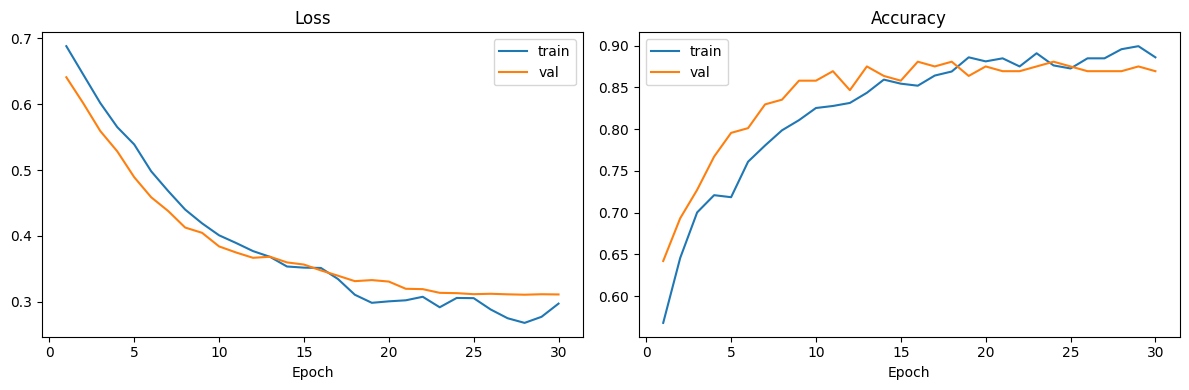

In [28]:
epochs = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['train_loss'], label='train')
ax1.plot(epochs, history['val_loss'],   label='val')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(epochs, history['train_acc'], label='train')
ax2.plot(epochs, history['val_acc'],   label='val')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

## 9. Evaluation on Test Set

In [29]:
# Load best checkpoint
model.load_state_dict(torch.load('best_eegnet.pt', map_location=DEVICE))

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(DEVICE)).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(yb)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

print(classification_report(all_labels, all_preds, target_names=le.classes_))

              precision    recall  f1-score   support

   alcoholic       0.80      0.90      0.85        81
     control       0.91      0.81      0.86        95

    accuracy                           0.85       176
   macro avg       0.85      0.86      0.85       176
weighted avg       0.86      0.85      0.85       176



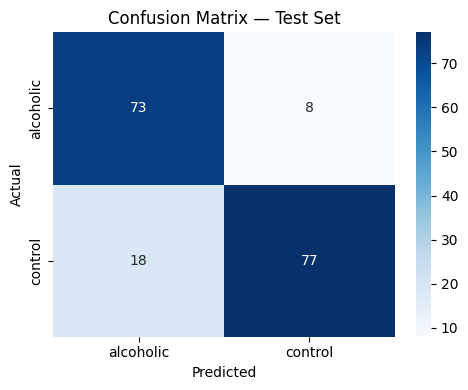

In [30]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

## 10. Next Steps

| Direction | Idea |
|---|---|
| **Features** | Add stimulus condition (`S1`, `S1+S2 matched`, `S1+S2 non-matched`) as an extra input or run separate models per condition |
| **Preprocessing** | Band-pass filter (1–40 Hz), artifact rejection (eye blinks via ICA), z-score per channel |
| **Architecture** | Try a 1-D TCN (Temporal Convolutional Network) or a Transformer over time-steps |
| **Regularisation** | Subject-stratified k-fold CV (never split trials from the same subject across train/test) |
| **Interpretability** | Grad-CAM on the temporal/spatial filters to see which electrodes drive predictions |
| **Baseline** | Compare against an SVM on bandpower features (delta / theta / alpha / beta per channel) |